# Taller Análisis Exploratorio de Datos

## Paso 1: Carga de datos

Abra el archivo en Excel o bloc de notas, y revise sí hay algo particular con los datos. Este paso es importante para evitar problemas posteriores al cargar los datos.

Cargar el archivo dado, que contiene un dataset cuya información puede consultar en [UCI](https://archive.ics.uci.edu/dataset/27/credit+approval).

De a las columnas los siguientes nombres: 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15'.

Responda las siguientes preguntas:

- ¿Cuántas filas y columnas tiene el dataframe?
- ¿De qué tipo de dato es cada columna?
- ¿Las variables están en el tipo de dato correcto para su contenido?


In [5]:
import pandas as pd

df = pd.read_csv('crx.data', header=None, na_values='?')

df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,202.0,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,43.0,560,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,280.0,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,100.0,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,120.0,0,+


In [6]:
df.columns = [
    'A0','A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8',
    'A9', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15',
]

print("Dimensiones del dataframe:", df.shape)

print("\nTipos de datos:")
print(df.dtypes)

Dimensiones del dataframe: (690, 16)

Tipos de datos:
A0      object
A1     float64
A2     float64
A3      object
A4      object
A5      object
A6      object
A7     float64
A8      object
A9      object
A10      int64
A11     object
A12     object
A13    float64
A14      int64
A15     object
dtype: object


In [7]:
for columna in df.select_dtypes(include='object').columns:
    print(f"{columna}:")
    print(df[columna].unique())
    print()

A0:
['b' 'a' nan]

A3:
['u' 'y' nan 'l']

A4:
['g' 'p' nan 'gg']

A5:
['w' 'q' 'm' 'r' 'cc' 'k' 'c' 'd' 'x' 'i' 'e' 'aa' 'ff' 'j' nan]

A6:
['v' 'h' 'bb' 'ff' 'j' 'z' nan 'o' 'dd' 'n']

A8:
['t' 'f']

A9:
['t' 'f']

A11:
['f' 't']

A12:
['g' 's' 'p']

A15:
['+' '-']



**Respuestas punto #1**
- ¿Cuántas filas y columnas tiene el dataframe?: Tiene 690 filas  y 16 columnas.
- ¿De qué tipo de dato es cada columna?: Las columnas son respectivamente A0 object A1 float64 A2 float6 A3 objecto A4 objectA5 object A6 object A7 float64 A8 object A9 object A10 int64A 11 objectA 12 objectA 13 float64A 14 int64A 15 object
- ¿Las variables están en el tipo de dato correcto para su contenido?:


## Paso 2: Exploración inicial de los datos

Responda las siguientes preguntas:

- ¿Hay valores fuera de rango o imposibles, según el dominio del problema?
- ¿Hay variables que no varían?
- Qué variables *cualitativas* tienen muchos valores únicos (alta cardinalidad)?
- ¿Hay claves primarias o identificadores únicos?

In [10]:

df.nunique()

,0
A0,2
A1,349
A2,215
A3,3
A4,3
A5,14
A6,9
A7,132
A8,2
A9,2


In [13]:
df.select_dtypes(include='object').nunique().sort_values(ascending=False)

,0
A5,14
A6,9
A4,3
A3,3
A12,3
A0,2
A8,2
A9,2
A11,2
A15,2


In [14]:
df.nunique() == len(df)

,0
A0,False
A1,False
A2,False
A3,False
A4,False
A5,False
A6,False
A7,False
A8,False
A9,False


**Respuestas punto #2**
- No,todas las variables presentan mas de un valor unico, por lo tanto, no se identifican variables constantes o que no varíen en el dataset.
- Al revisar las variables cualitativas, se observa que A5 y A6 son las que tienen más valores diferentes, con 14 y 9 respectivamente. Las demás tienen entre 2 y 3 valores únicos. Por lo tanto, A5 y A6 son las variables cualitativas con mayor cantidad de categorías.
- No se encontraron claves primarias,todas presentan valores que se repiten dentro del dataset.

## Paso 3: Identificación de datos duplicados, datos nulos y problemas de formateo

Descarte las variables que solo toman un valor y las que son clave primaria. También descarte las variables **City** y **Lat Long**.

Responda las siguientes preguntas:

- ¿Qué variables tienen valores nulos? ¿En qué proporción?
- ¿Hay registros duplicados?
- ¿Hay variables con problemas de formateo (fechas, monedas, mayúsculas/minúsculas)?

In [15]:
nulos = df.isnull().sum()
porcentaje = (nulos / len(df)) * 100

pd.DataFrame({
    'Cantidad de nulos': nulos,
    'Porcentaje (%)': porcentaje
})

,Cantidad de nulos,Porcentaje (%)
A0,12,1.739130
A1,12,1.739130
A2,0,0.000000
A3,6,0.869565
A4,6,0.869565
A5,9,1.304348
A6,9,1.304348
A7,0,0.000000
A8,0,0.000000
A9,0,0.000000


In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
for columna in df.select_dtypes(include='object').columns:
    print(columna, df[columna].dropna().unique())

A0 ['b' 'a']
A3 ['u' 'y' 'l']
A4 ['g' 'p' 'gg']
A5 ['w' 'q' 'm' 'r' 'cc' 'k' 'c' 'd' 'x' 'i' 'e' 'aa' 'ff' 'j']
A6 ['v' 'h' 'bb' 'ff' 'j' 'z' 'o' 'dd' 'n']
A8 ['t' 'f']
A9 ['t' 'f']
A11 ['f' 't']
A12 ['g' 's' 'p']
A15 ['+' '-']


- ¿Qué variables tienen valores nulos? ¿En qué proporción?: A0 12 A1 12 A3 6 A4 6 A5 9 A6 9 A13 13
- ¿Hay registros duplicados?: No hay registros duplicados
- ¿Hay variables con problemas de formateo (fechas, monedas, mayúsculas/minúsculas)?: No se observan problemas de formato en las variables. Los valores categóricos mantienen un formato consistente y no se encontraron diferencias por mayúsculas o minúsculas.


## Paso 4: Análisis de variables cuantitativas

Haga análisis de normalidad de las variables cuantitativas. Indique cuáles variables cumplen con el supuesto de normalidad y cuáles no.

Haga un análisis gráfico de outliers, y como resultado de este indique que variables tienen datos atípicos.

In [19]:
from scipy.stats import shapiro

numericas = ['A1', 'A2', 'A7', 'A10', 'A13', 'A14']

for columna in numericas:
    datos = df[columna].dropna()
    p = shapiro(datos).pvalue

    if p > 0.05:
        print(columna, "-> Normal")
    else:
        print(columna, "-> No normal")

A1 -> No normal
A2 -> No normal
A7 -> No normal
A10 -> No normal
A13 -> No normal
A14 -> No normal


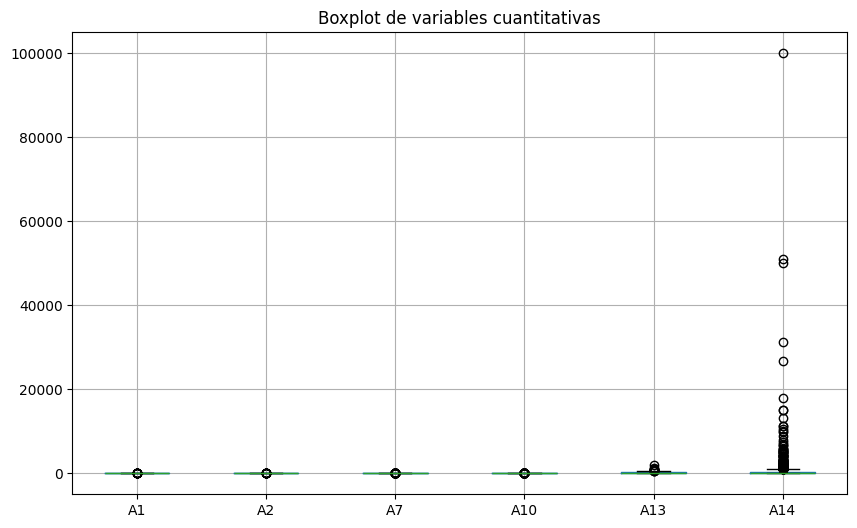

In [20]:
import matplotlib.pyplot as plt

numericas = ['A1', 'A2', 'A7', 'A10', 'A13', 'A14']

df[numericas].boxplot(figsize=(10, 6))

plt.title("Boxplot de variables cuantitativas")
plt.show()

- Haga análisis de normalidad de las variables cuantitativas. Indique cuáles variables cumplen con el supuesto de normalidad y cuáles no: ninguna cumple el supuesto de normalidad
- Haga un análisis gráfico de outliers, y como resultado de este indique que variables tienen datos atípicos.

## Paso 5: Análisis de variables cualitativas

Responda a las siguientes preguntas:

- ¿Cómo se comportan las variables categóricas?
- ¿Existen variables de alta cardinalidad?
- ¿Existen categorías atípicas?

In [21]:
categoricas = df.select_dtypes(include='object').columns

for columna in categoricas:
    print("\n", columna)
    print(df[columna].value_counts())


 A0
A0
b    468
a    210
Name: count, dtype: int64

 A3
A3
u    519
y    163
l      2
Name: count, dtype: int64

 A4
A4
g     519
p     163
gg      2
Name: count, dtype: int64

 A5
A5
c     137
q      78
w      64
i      59
aa     54
ff     53
k      51
cc     41
x      38
m      38
d      30
e      25
j      10
r       3
Name: count, dtype: int64

 A6
A6
v     399
h     138
bb     59
ff     57
j       8
z       8
dd      6
n       4
o       2
Name: count, dtype: int64

 A8
A8
t    361
f    329
Name: count, dtype: int64

 A9
A9
f    395
t    295
Name: count, dtype: int64

 A11
A11
f    374
t    316
Name: count, dtype: int64

 A12
A12
g    625
s     57
p      8
Name: count, dtype: int64

 A15
A15
-    383
+    307
Name: count, dtype: int64


In [22]:
df.select_dtypes(include='object').nunique().sort_values(ascending=False)

,0
A5,14
A6,9
A4,3
A3,3
A12,3
A0,2
A8,2
A9,2
A11,2
A15,2


- ¿Cómo se comportan las variables categóricas? : Las variables categóricas presentan diferentes cantidades de categorías. En algunas variables los datos están bastante repartidos, como en A8, A9, A11 y A15.
- ¿Existen variables de alta cardinalidad?: Las variables con mayor cantidad de categorías son A5 con 14 y A6 con 9. Por lo tanto, son las variables categóricas con mayor cardinalidad del dataset.
- ¿Existen categorías atípicas?: Se posdria decir que las categoricas como gg o l y r

## Paso 6: Análisis bivariado

Se va a suponer que con este archivo de datos se desea hacer un modelo de aprendizaje de máquina que prediga la vaariable **A15**.


Mediante análisis de gráficas responda las siguientes preguntas:

- ¿Cómo se relaciona cada una de las variables cuantitativas con la variable que se desea predecir?
- ¿Cómo se relaciona cada una de las variables cualitativas con la variable que se desea predecir?
- De acuerdo con estos análisis, ¿cuáles variables parecerían ser buenas predictoras, y cuáles no?


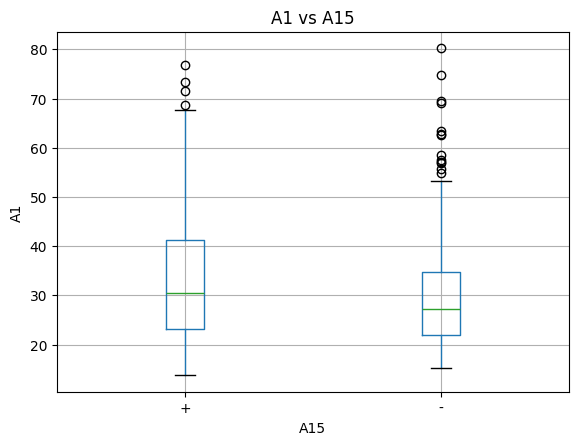

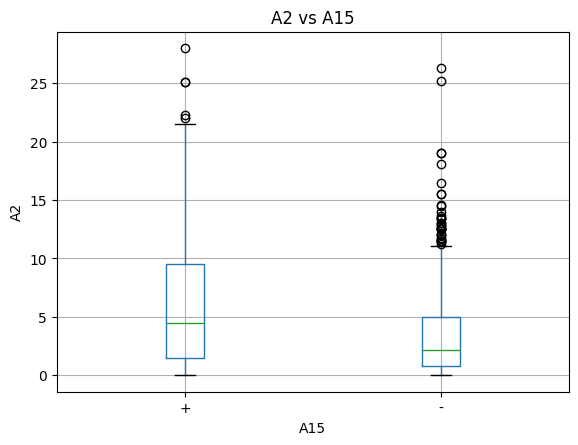

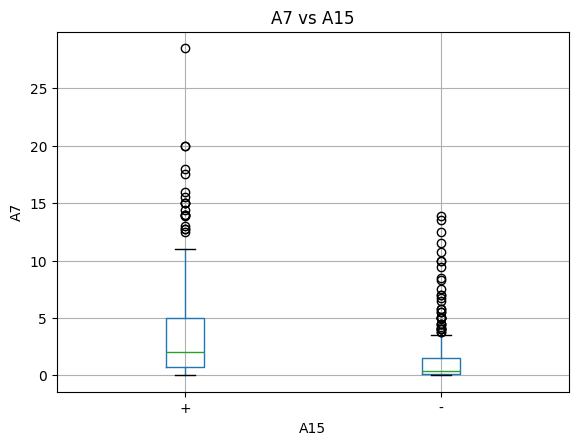

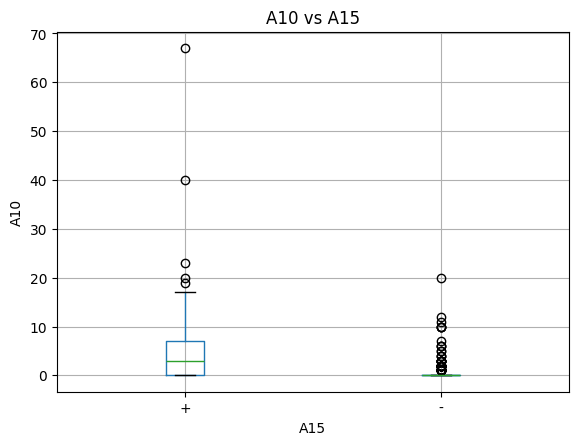

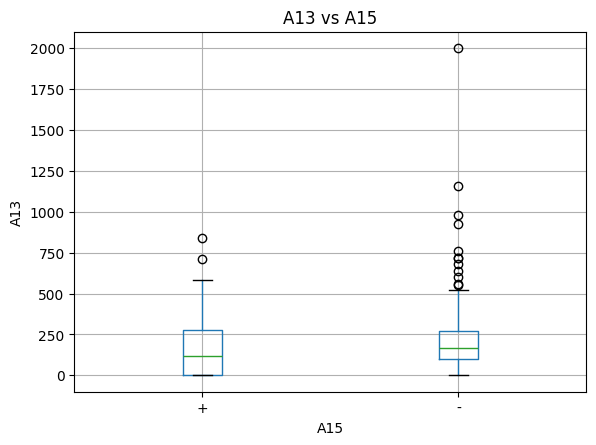

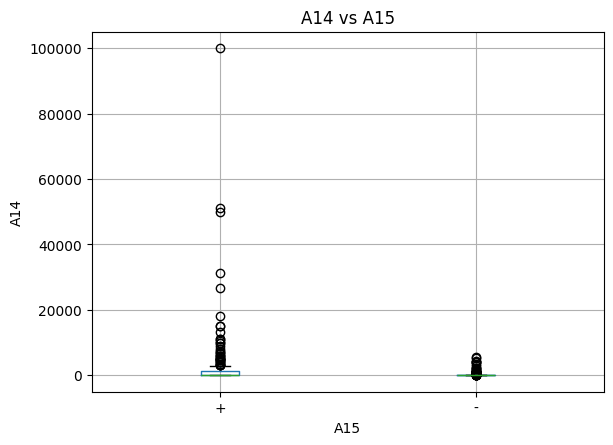

In [23]:
import matplotlib.pyplot as plt

numericas = ['A1', 'A2', 'A7', 'A10', 'A13', 'A14']

for columna in numericas:
    df.boxplot(column=columna, by='A15')
    plt.title(columna + " vs A15")
    plt.suptitle("")
    plt.xlabel("A15")
    plt.ylabel(columna)
    plt.show()

Al comparar las variables cuantitativas con A15, se observa que A2 y A7 muestran diferencias más claras entre las categorías positiva (+) y negativa (-), por lo que podrían tener una mayor relación con la variable que se quiere predecir. En A1 la diferencia entre los dos grupos es menor.